### 히트맵(Heatmap)

숫자 데이터를 표(격자) 형태로 배치하고, **값의 크기를 색깔로** 나타낸 그래프. 
숫자를 하나하나 읽지 않아도 "색이 진한 곳 = 값이 크다"를 한눈에 파악할 수 있다.

**핵심 아이디어**
- 행(row)과 열(column)의 교차점마다 값이 있고, 그 값의 크기에 따라 색이 달라짐
- 색이 진하거나 밝을수록 값이 크고, 반대로 연하거나 어두울수록 값이 작음 (사용하는 색상표에 따라 방향은 다를 수 있음)

**주로 쓰이는 경우**

| 용도 | 예시 |
|---|---|
| 상관관계 파악 | 여러 변수 간 관계를 표 하나로 확인 |
| 시간 x 항목 패턴 | 요일별 x 카테고리별 주문 건수 |
| 지리적 분포 | 지역별 x 상품별 평균 가격 |
| 대용량 데이터 탐색 | 수천 개 변수를 한눈에 훑어보기 |

> 💡 히트맵은 "정확한 숫자"보다 "**상대적으로 어디가 크고 작은지**"를 빠르게 파악하는 데 특화된 시각화 방법이다.

키 나이 몸무게  시력 성격

In [2]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


print("연결 및 쿼리 성공! 데이터 shape:", df.shape)
df.head()


연결 및 쿼리 성공! 데이터 shape: (37, 7)


C:\Users\soldesk\AppData\Local\Temp\ipykernel_6028\240803744.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


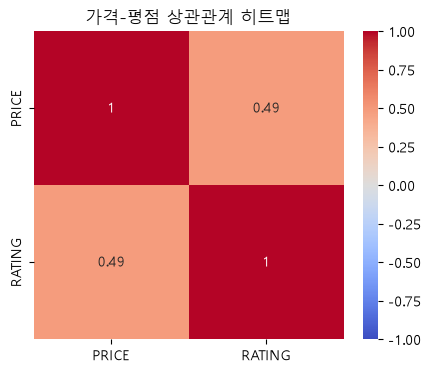

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

import seaborn as sns

numeric_df = df[["PRICE", "RATING"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("가격-평점 상관관계 히트맵")
plt.show()

In [ ]:
## 카테고리를 숫자로 바꿔서(원-핫 인코딩) 상관관계 살펴보기
# 예) 주문이 치킨이면 1, 아니면 0
# CATEGORY를 0/1 더미 변수로 변환
category_dummies = pd.get_dummies(df["CATEGORY"], prefix="CAT")
print("=== 원-핫 인코딩 결과 (앞 5행) ===")
print(category_dummies.head())

# 원본 숫자 컬럼(PRICE, RATING)과 더미 컬럼을 옆으로 이어붙임
# axis = 1 열을 새로 생성하여 결과값 추가
extended_df = pd.concat([df[["PRICE", "RATING"]], category_dummies], axis=1)
extended_corr = extended_df.corr()
print(extended_df)

print("\n=== 확장된 상관관계 행렬 shape ===")
print(extended_corr.shape)

=== 원-핫 인코딩 결과 (앞 5행) ===
   CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0    True   False   False   False   False
1   False   False   False    True   False
2   False   False   False   False    True
3   False   False    True   False   False
4   False   False    True   False   False
    PRICE  RATING  CAT_분식  CAT_일식  CAT_중식  CAT_치킨  CAT_피자
0    9000     4.5    True   False   False   False   False
1   22000     4.8   False   False   False    True   False
2   25000     4.2   False   False   False   False    True
3    8000     4.0   False   False    True   False   False
4   13000     4.6   False   False    True   False   False
5   11000     4.3   False    True   False   False   False
6   18000     4.4   False   False    True   False   False
7    8500     4.3    True   False   False   False   False
8    7000     4.1    True   False   False   False   False
9   21000     4.7   False   False   False    True   False
10  23000     4.9   False   False   False    True   False
11  22000     4.6   False 

# seaborn 히트맵 — 상관관계 시각화

* 숫자 컬럼 2개짜리 단순 히트맵을 넘어, **범주형 데이터를 숫자로 바꿔서(원-핫 인코딩)** 상관관계를 확장
* `ORDER_DATE`에서 **요일을 뽑아내** "요일 x 카테고리" 조합의 주문 패턴을 히트맵으로 구현
* `clustermap`으로 "비슷하게 움직이는 카테고리끼리 자동으로 묶어서" 보는 법